In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

sns.set_theme()

Seaborn comes with a bunch od datasets built-in:

In [2]:
tips = sns.load_dataset('tips')

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Distribution plots

This type of plot displays the distribution of uni-variate set of obesrvations:

<Axes: xlabel='total_bill', ylabel='Density'>

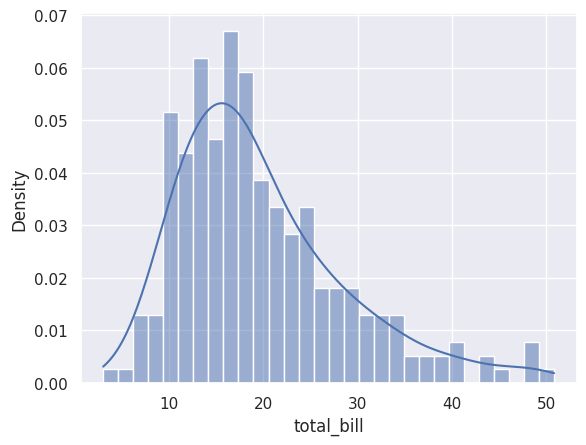

In [3]:
# KDE stands for Kernel Density Estimation
sns.histplot(data=tips, x="total_bill", bins=30, kde=True, stat="density")

Joint-plots display the distribution of bi-variate set of observations (combines two distribution plots):

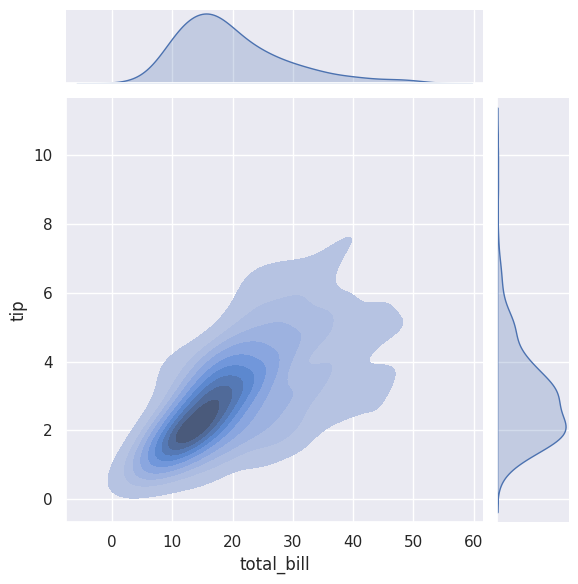

In [4]:
# display the distribution of total bill vs. the tip size
sns.jointplot(x="total_bill", y="tip", data=tips, kind="kde", fill=True)

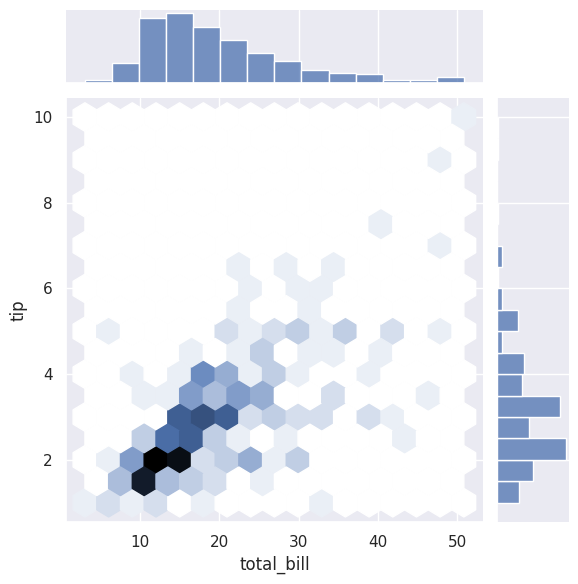

In [5]:
sns.jointplot(x="total_bill", y="tip", data=tips, kind="hex")


Display pair-wise relationships across the entire data-frame:

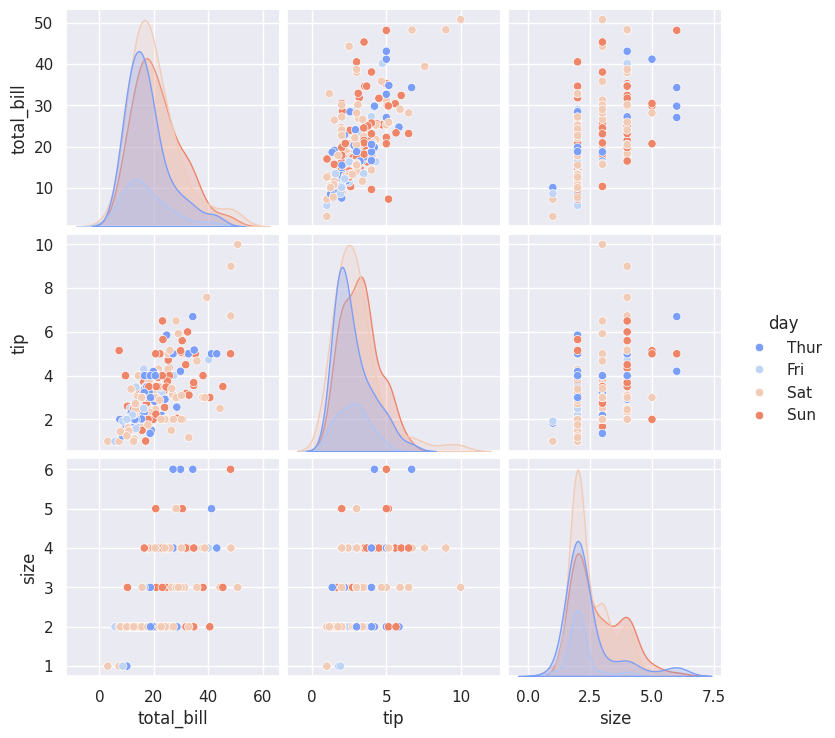

In [6]:
# the hue= param usually points to a "categorical" column
sns.pairplot(data=tips, hue="day", palette="coolwarm")

Rugplots are another way to vizualize uni-variate observation sets:

<Axes: xlabel='total_bill'>

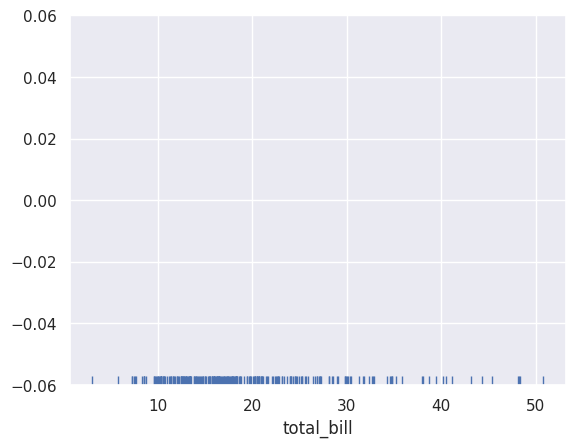

In [7]:
sns.rugplot(data=tips, x="total_bill")

### Kernel Density Estimation (KDE)

Starting from a rugplot, we create a normal distribution around each point of a rugplot; we then **add** all those normal distributions to obtain the final KDE shape.

(0.0, 1.0)

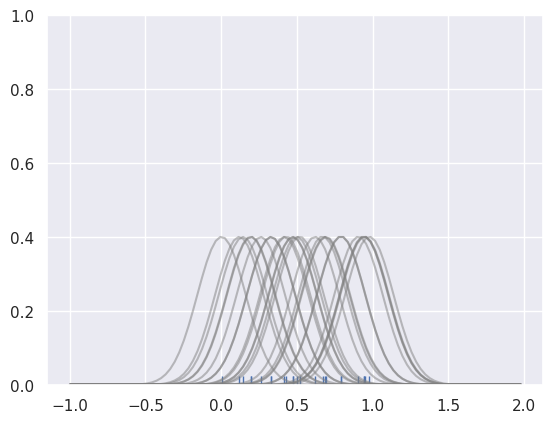

In [8]:
dataset = np.random.rand(25)

fig, ax = plt.subplots()

sns.rugplot(data=dataset, ax=ax)

x_min = dataset.min() - 1
x_max = dataset.max() + 1

x_values = np.linspace(x_min, x_max, 100)

# see
bandwidth = ((4*dataset.std()**5)/(3*len(dataset)))**.2

kernels = []

for data_point in dataset:
    # Create a kernel for each point and append to list
    kernel = stats.norm(data_point,bandwidth).pdf(x_values)
    kernels.append(kernel)
    
    #Scale for plotting
    kernel = kernel / kernel.max()
    kernel = kernel * .4
    plt.plot(x_values, kernel, color = 'grey', alpha=0.5)

ax.set_ylim((0, 1))

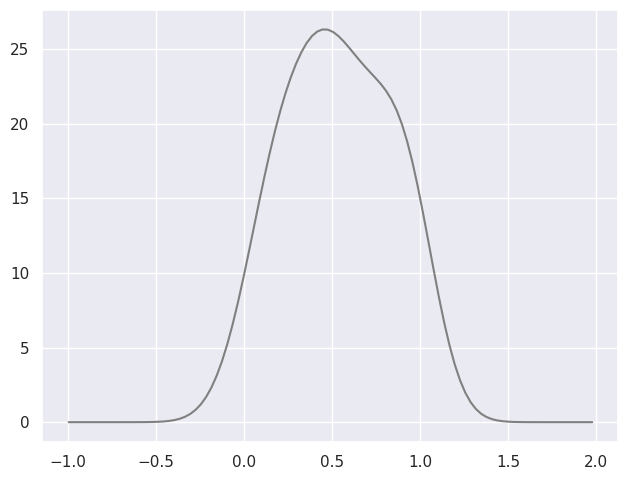

In [9]:
fig = plt.figure()

axes = fig.add_axes((.1, .1, .9, .9))

# Plot the sum of the basis function
sum_of_kde = np.sum(kernels, axis=0)
axes.plot(x_values, sum_of_kde, color = 'grey')

## Categorical plots

These plots all receive three main input paramters:
 - `x=`: a numerical set of observations (column in a data-frame)
 - `y=`: a categorical set of obesrvations (column in a data-frame)
 - `data=`: the dataset (i.e. the data-frame itself)

The goal is to provide a visual representation of the numerical data "broken-down" by the classes in the categorical data (think "group-by" in visual form).

There is an optional 4th argument (`hue=`), which is yet another categorical set of observation providing an additional level of break-down.

### Bar plots

The default aggregator function is `mean()`, but you can swap that for any other aggregation function you want (even provide you own custom aggregator).

The small vertical line (error bar) represents:
 - **95% confidence interval** by default (seaborn uses bootstrapping)
 - Shows the range where the true population mean likely falls
 - Longer line = more uncertainty in the estimate

`sns.barplot(data=tips, x="day", y="total_bill")`

In short:
  - **Bar height** = mean total_bill for each day
  - **Error bar** = 95% confidence interval around that mean

Can customize with:
  - `errorbar="sd"` - show standard deviation instead
  - `errorbar=None` - hide error bars

<Axes: xlabel='day', ylabel='total_bill'>

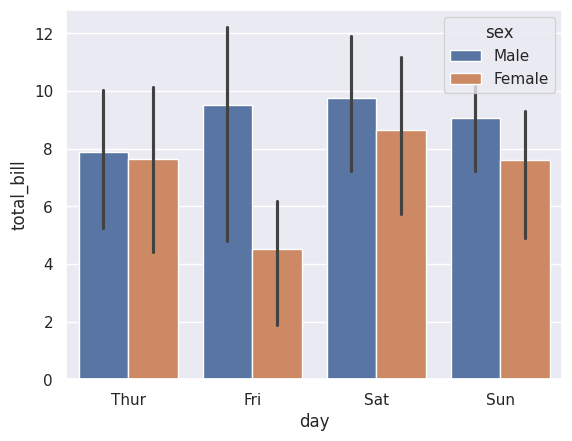

In [10]:
fig, ax = plt.subplots()

sns.barplot(x="day", y="total_bill", data=tips, hue="sex", estimator=np.std, ax=ax)

### Count plots

This is basically the same as `barplot()`, but the aggregator is the `count()` function - this means you don't need to provide and `estimator=` or a numerical set of observations (i.e. the `y=` param). 

<Axes: xlabel='day', ylabel='count'>

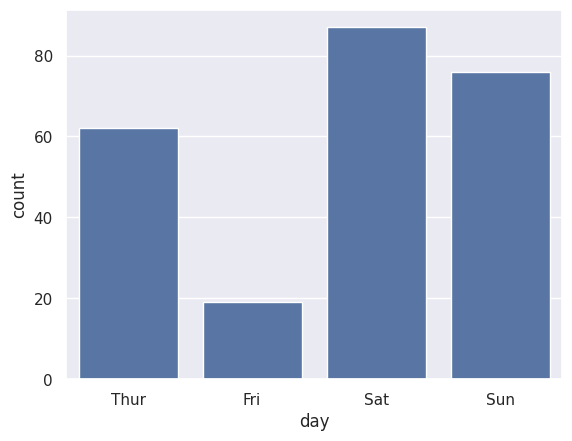

In [11]:
fig, ax = plt.subplots()

sns.countplot(x="day", data=tips, ax=ax)

### Box plots

Displays the distribution of a numeric variable across categories via quartiles.

**Visual elements:**
- **Box:** Interquartile range (IQR) - middle 50% of the data (25th to 75th percentile)
- **Line inside box:** Median of the data
- **Whiskers:** Extend to 1.5× IQR below/above the box (shows expected range of non-outlier data)
- **Dots:** Outliers beyond the whiskers

Quick reference:

```
      |----|-----|----|----|   ← whiskers (1.5× IQR)
           +-----+             ← box (25th to 75th percentile)
              |              ← median line
              o              ← outlier (beyond whiskers)
```              

<Axes: xlabel='day', ylabel='total_bill'>

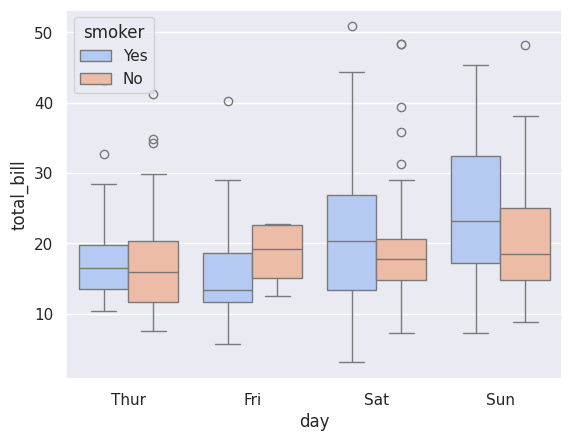

In [12]:
fig, ax = plt.subplots()

sns.boxplot(x="day", y="total_bill", data=tips, hue="smoker", ax=ax, palette="coolwarm")

### Violin plots

Combines a boxplot with a KDE - shows the full distribution shape.

**Visual elements**:
  - **Outer shape (violin)**: KDE mirrored - shows data density at each value (wider = more data points)
- **Inner box**: Same as boxplot (IQR, median line, whiskers for expected range)
- **Dots/points**: Individual data points (optional, with `inner="points"`)

Quick reference:
```
      _____________
     /             \     ← KDE (mirrored density)
    /    +-----+    \
   /     |  |  |     \    ← box inside (IQR + median)
  /      +-----+      \
 /_____________________\
```

Use when you want:
  - To see the full distribution shape (not just summary stats)
  - Compare distributions across categories
  - See if data is multimodal

**NOTE**: the optional `split=True` allows for the extra breakdown imposed by `hue=` to be viewed side-by-side (each hue categoory occupies half the violin).

<Axes: xlabel='sex', ylabel='tip'>

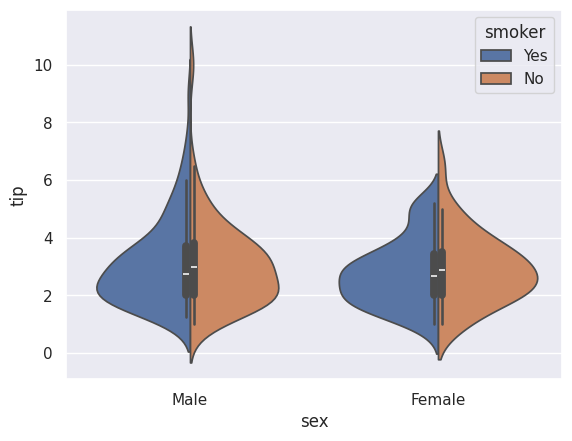

In [13]:
fig, ax = plt.subplots()

sns.violinplot(x="sex", y="tip", data=tips, hue="smoker", split=True, ax=ax)

### Strip plots

Displays individual data points along a categorical axis as a scatter plot.

**Visual elements**:
- **Each dot**: One individual observation from the dataset
- **Position**: Plotted along both x (category) and y (value) axes
- **Jitter (horizontal scatter)**: Added randomly to prevent overlapping identical points

Quick reference:
```
         o    o      
        o  o o   o     ← individual points (one per observation)
   -----+-----+-----+----
        Thur Fri Sat Sun   ← categories
```

Use when you want:
  - See actual data points (not just summary stats)
  - Sample size is small enough to not overcrowd
  - Combine with boxplot/violinplot for extra detail: `sns.boxplot(...) + sns.stripplot(...)`

Common options:
  - jitter=True (default) - spreads points horizontally to reduce overlap
  - dodge=True - separate by hue category
  - alpha=0.5 - transparency for overlapping points

<Axes: xlabel='sex', ylabel='tip'>

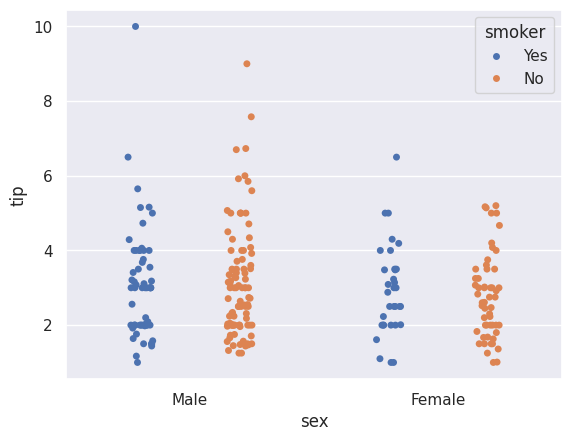

In [14]:
fig, ax = plt.subplots()

sns.stripplot(x="sex", y="tip", data=tips, hue="smoker", dodge=True, ax=ax)

### Swarm plots

Displays individual data points along a categorical axis WITHOUT overlapping - each point has its own space.

**Visual elements**:
  - **Each dot**: One individual observation
  - **Position**: Plotted along x (category) and y (value), but points don't overlap
  - **Algorithm**: Points spread horizontally to avoid overlap while staying near their true value

Quick reference:
```
         o o o      
        o o o o   o     ← individual points (no overlap in x direction)
   -----+-----+-----+----
        Thur Fri Sat Sun
```

Use when you want:
  - See every data point without overlap (unlike stripplot)
  - Medium sample sizes (~100-500)
  - Combined with boxplot/violinplot: `sns.boxplot(...) + sns.swarmplot(...)`

Caveat:
  - Can get slow with very large datasets (points calculated individually)
  - Not suitable for thousands of points

<Axes: xlabel='sex', ylabel='tip'>

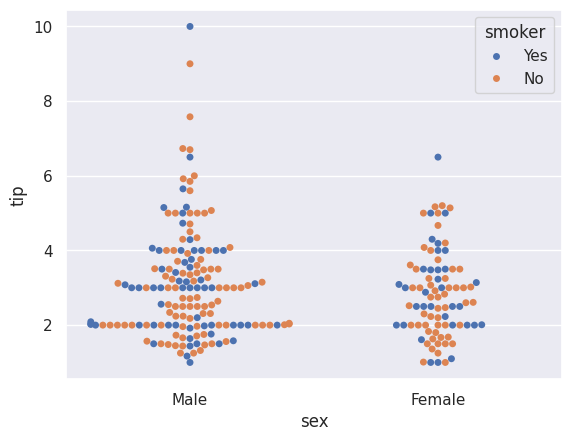

In [15]:
fig, ax = plt.subplots()

sns.swarmplot(x="sex", y="tip", data=tips, hue="smoker", ax=ax)

You can combine `swarmplot` with `violinplot` for visual impact:

<Axes: xlabel='sex', ylabel='tip'>

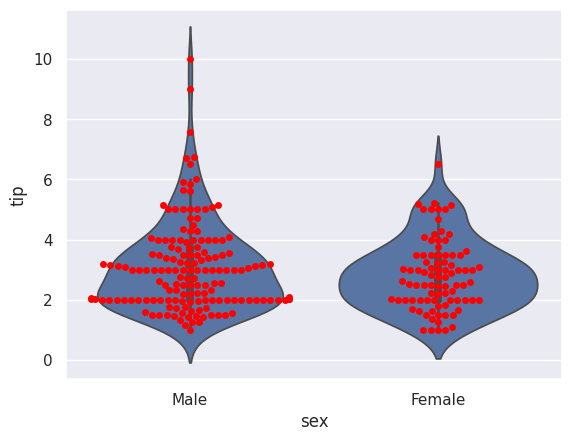

In [16]:

fig, ax = plt.subplots()

sns.swarmplot(x="sex", y="tip", data=tips, ax=ax, color="red")
sns.violinplot(x="sex", y="tip", data=tips, ax=ax)

### Cat plots

`factorplot` was the old name for `catplot` (renamed in seaborn v0.9+).

**Purpose**: Figure-level interface for categorical plots - automatically creates subplots for different hue levels.

**Visual elements**: Same as the underlying plot type specified by kind=, but creates a figure-level plot with optional row/col facets.

Use when you want:
  - Automatic faceting by multiple hue levels
  - Row/col subplot layouts
  - Consistent figure-level interface

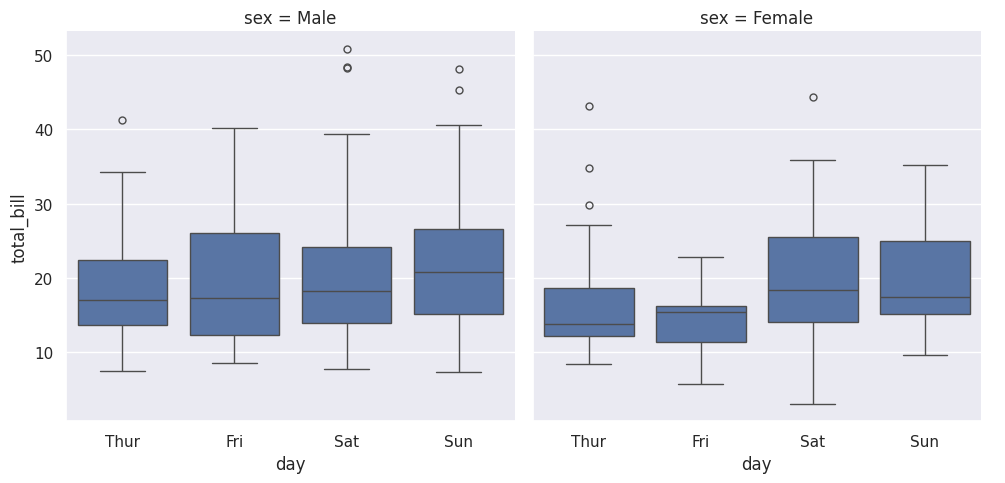

In [17]:
sns.catplot(data=tips, x="day", y="total_bill", col="sex", kind="box")

## Matrix plots

**NOTE:** in order to be able to plot these type of charts, the data needs to be in the so-called _matrix form_: both the rows and the columns need to be indexed based on some variable in the data-frame.

This can be easily achieved using a pivot table.

In [18]:
flights = sns.load_dataset('flights')

flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [19]:
df = flights.pivot_table(index="month", columns="year", values="passengers")

display(df)

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


### Heat-maps

Probably the most pupilat type of matrix plots.

<Axes: xlabel='year', ylabel='month'>

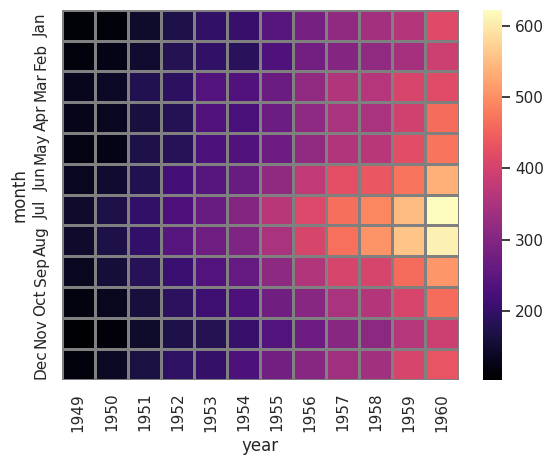

In [20]:
sns.heatmap(df, cmap="magma", linecolor="grey", linewidths=1)

### Cluster-maps

In a cluster-maps, the rows / columns are _re-arranged_ to bring together (clusterize) values that are "similar" to each other.

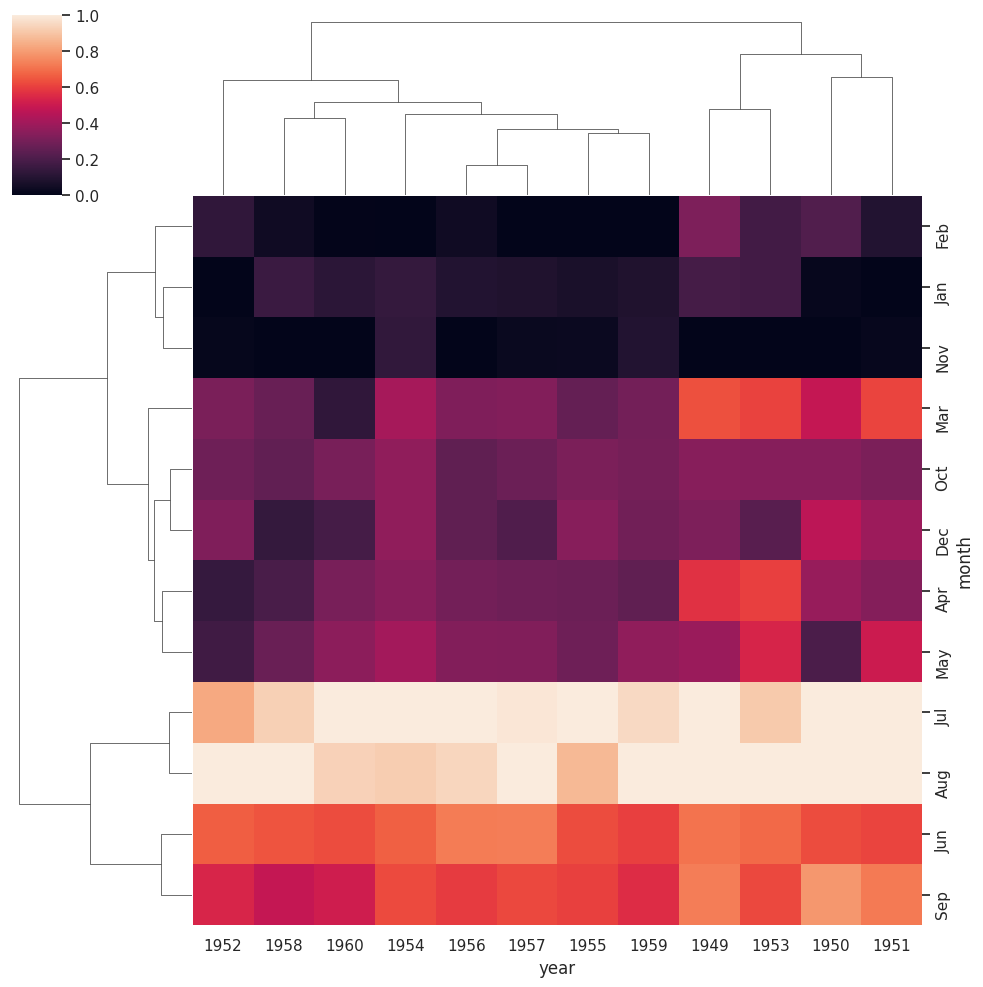

In [21]:
# with the standard_scale= kw param we normalize the values to the desired range
sns.clustermap(df, standard_scale=1)

## Regression plots

With `lmplot()` you get a _scatter plot_ with a _linear fit_ superimposed on top (the name function stans for _linear model plot_).

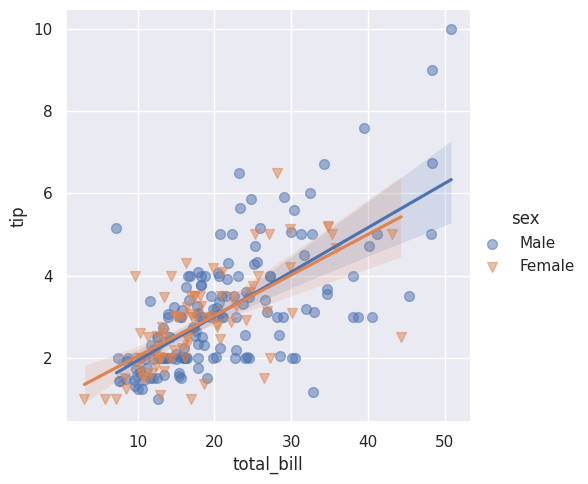

In [22]:
sns.lmplot(
    x="total_bill",
    y="tip",
    data=tips,
    hue="sex", # controls color
    hue_order=["Male", "Female"],
    markers=["o", "v"],  # type: ignore[arg-type]

    # control various styling aspects
    scatter_kws= {
        "s": 50,
        "alpha": 0.5
    }
)

If you deal with multiple categories, you can split the plot into a grid:

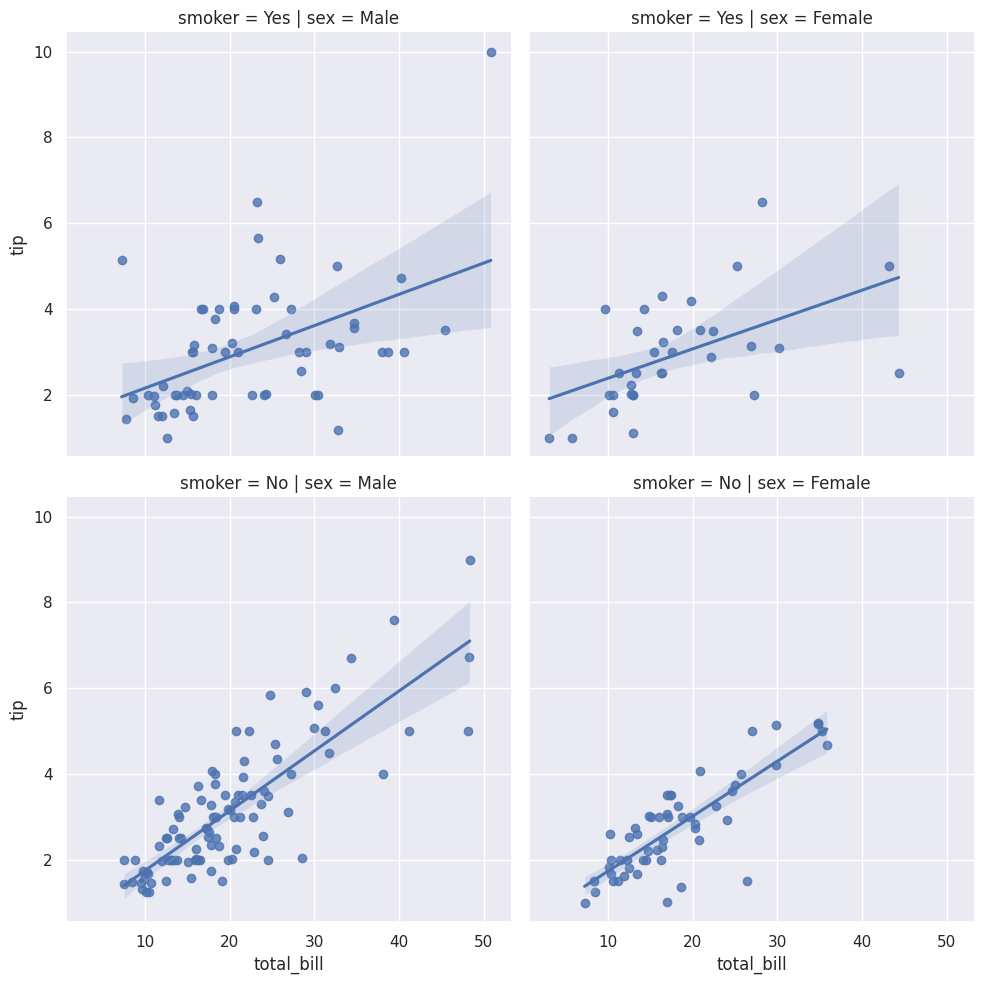

In [23]:
sns.lmplot(x="total_bill", y="tip", data=tips, col="sex", row="smoker")

The shaded area in `lmplot()` is a confidence interval for the fitted mean line. A prediction interval is wider because it estimates where a new individual tip might fall. The example below uses `statsmodels` with the same `tips` dataset so you can compare both intervals on one chart.

Read the next cell in three passes: `smf.ols(...).fit()` learns the regression line, `get_prediction(...).summary_frame()` computes the fitted mean together with the confidence and prediction intervals on a smooth `total_bill` grid, and the Matplotlib calls draw the observed points, the fitted line, and the two shaded bands.

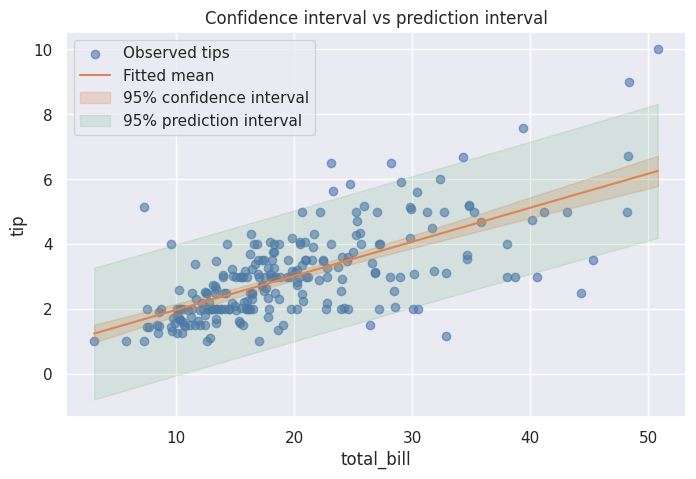

In [ ]:
import statsmodels.formula.api as smf

model = smf.ols("tip ~ total_bill", data=tips).fit()

x_grid = np.linspace(tips["total_bill"].min(), tips["total_bill"].max(), 200)
prediction_input = pd.DataFrame({"total_bill": x_grid})
prediction = model.get_prediction(prediction_input).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(tips["total_bill"], tips["tip"], alpha=0.6, label="Observed tips")
ax.plot(x_grid, prediction["mean"], color="C1", label="Fitted mean")

ax.fill_between(
    x_grid,
    prediction["mean_ci_lower"],
    prediction["mean_ci_upper"],
    color="C1",
    alpha=0.25,
    label="95% confidence interval",
)

ax.fill_between(
    x_grid,
    prediction["obs_ci_lower"],
    prediction["obs_ci_upper"],
    color="C2",
    alpha=0.15,
    label="95% prediction interval",
)

ax.set(
    title="Confidence interval vs prediction interval",
    xlabel="total_bill",
    ylabel="tip",
)
ax.legend()
plt.show()